# Explora aquí

Se recomienda utilizar este cuaderno con fines de exploración.

### Paso 1: Instalación de dependencias

In [194]:
pip install pandas requests

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


### Paso 2: Descargar HTML

In [195]:
import os
from bs4 import BeautifulSoup
import requests
import time
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns

url= "https://companies-market-cap-copy.vercel.app/index.html"

response = requests.get(url)
if response.status_code != 200:
    raise Exception(f"Error al acceder a la página: {response.status_code}")


response.text

'\n<!DOCTYPE html>\n<html lang="en-US">\n<head>\n<title>Tesla (TSLA) - Revenue</title>\n<meta charset="utf-8"/>\n<link rel="shortcut icon" href="https://companiesmarketcap.com/favicon.ico" type="image/x-icon">\n<link rel="apple-touch-icon" sizes="57x57" href="/img/icons/apple-icon-57x57.png">\n<link rel="apple-touch-icon" sizes="60x60" href="/img/icons/apple-icon-60x60.png">\n<link rel="apple-touch-icon" sizes="72x72" href="/img/icons/apple-icon-72x72.png">\n<link rel="apple-touch-icon" sizes="76x76" href="/img/icons/apple-icon-76x76.png">\n<link rel="apple-touch-icon" sizes="114x114" href="/img/icons/apple-icon-114x114.png">\n<link rel="apple-touch-icon" sizes="120x120" href="/img/icons/apple-icon-120x120.png">\n<link rel="apple-touch-icon" sizes="144x144" href="/img/icons/apple-icon-144x144.png">\n<link rel="apple-touch-icon" sizes="152x152" href="/img/icons/apple-icon-152x152.png">\n<link rel="apple-touch-icon" sizes="180x180" href="/img/icons/apple-icon-180x180.png">\n<link rel="ic

### Paso 3: Transforma el HTML

In [196]:
soup = BeautifulSoup(response.text, "html.parser")

tablas = soup.find("table")

tablas

<table class="table" style="width:100%">
<thead>
<tr>
<th>Year</th>
<th>Revenue</th>
<th>Change</th>
</tr>
</thead>
<tbody>
<tr><td><span class="year">2024</span></td><td>$97.15 B</td><td class="percentage-green">0.39%</td></tr><tr><td><span class="year">2023</span> </td><td>$96.77 B</td><td class="percentage-green">18.8%</td></tr><tr><td><span class="year">2022</span></td><td>$81.46 B</td><td class="percentage-green">51.35%</td></tr><tr><td><span class="year">2021</span></td><td>$53.82 B</td><td class="percentage-green">70.67%</td></tr><tr><td><span class="year">2020</span></td><td>$31.53 B</td><td class="percentage-green">28.31%</td></tr><tr><td><span class="year">2019</span></td><td>$24.57 B</td><td class="percentage-green">14.52%</td></tr><tr><td><span class="year">2018</span></td><td>$21.46 B</td><td class="percentage-green">82.51%</td></tr><tr><td><span class="year">2017</span></td><td>$11.75 B</td><td class="percentage-green">67.98%</td></tr><tr><td><span class="year">2016</span

In [197]:
print(f"Se encontraron {len(tablas)} tablas en la página.")

Se encontraron 5 tablas en la página.


In [198]:
encabezados_tablas = [header.text.strip() for header in tablas.find_all("th")]

encabezados_tablas

['Year', 'Revenue', 'Change']

In [199]:
rows = tablas.find_all("tr")

# Procesar datos de la tabla
data = []
for row in rows[1:]:  # Saltar la fila de encabezado
    cols = row.find_all("td")
    if cols:  # Asegurarse de que la fila tenga celdas de datos
        row_data = [col.text.strip() for col in cols]
        if len(row_data) == len(encabezados_tablas):
            data.append(row_data)

data            


[['2024', '$97.15 B', '0.39%'],
 ['2023', '$96.77 B', '18.8%'],
 ['2022', '$81.46 B', '51.35%'],
 ['2021', '$53.82 B', '70.67%'],
 ['2020', '$31.53 B', '28.31%'],
 ['2019', '$24.57 B', '14.52%'],
 ['2018', '$21.46 B', '82.51%'],
 ['2017', '$11.75 B', '67.98%'],
 ['2016', '$7.00 B', '73.01%'],
 ['2015', '$4.04 B', '26.5%'],
 ['2014', '$3.19 B', '58.85%'],
 ['2013', '$2.01 B', '387.23%'],
 ['2012', '$0.41 B', '102.34%'],
 ['2011', '$0.20 B', '74.95%'],
 ['2010', '$0.11 B', '4.29%'],
 ['2009', '$0.11 B', '']]

In [200]:
# Crear un DataFrame con los datos extraídos
df_tesla_beneficios = pd.DataFrame(data, columns=encabezados_tablas)
df_tesla_beneficios

,Year,Revenue,Change
0,2024,$97.15 B,0.39%
1,2023,$96.77 B,18.8%
2,2022,$81.46 B,51.35%
3,2021,$53.82 B,70.67%
4,2020,$31.53 B,28.31%
5,2019,$24.57 B,14.52%
6,2018,$21.46 B,82.51%
7,2017,$11.75 B,67.98%
8,2016,$7.00 B,73.01%
9,2015,$4.04 B,26.5%


### Paso 4: Procesa el DataFrame

In [205]:
# Renombrar columnas 
if 'Year' in df_tesla_beneficios.columns:
    df_tesla_beneficios.rename(columns={'Year': 'fecha'}, inplace=True)
if 'Revenue' in df_tesla_beneficios.columns:
    df_tesla_beneficios.rename(columns={'Revenue': 'Ingresos'}, inplace=True)

In [207]:
if 'Ingresos' in df_tesla_beneficios.columns:
    # Asegurarse de que la columna 'Ingresos' sea de tipo string antes de usar .str
    df_tesla_beneficios['Ingresos'] = df_tesla_beneficios['Ingresos'].astype(str)
    df_tesla_beneficios['Ingresos'] = df_tesla_beneficios['Ingresos'].str.replace(r'\$|B', '', regex=True).str.replace(',', '', regex=True).str.strip()
    df_tesla_beneficios['Ingresos'] = pd.to_numeric(df_tesla_beneficios['Ingresos'], errors='coerce')
    df_tesla_beneficios.dropna(subset=['Ingresos'], inplace=True)
    if 'fecha' in df_tesla_beneficios.columns:
        df_tesla_beneficios.dropna(subset=['fecha'], inplace=True)

print("\nDataFrame procesado:")
print(df_tesla_beneficios.head())
print(df_tesla_beneficios.info())


DataFrame procesado:
  fecha  Ingresos  Change
0  2024     97.15   0.39%
1  2023     96.77   18.8%
2  2022     81.46  51.35%
3  2021     53.82  70.67%
4  2020     31.53  28.31%
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16 entries, 0 to 15
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   fecha     16 non-null     object 
 1   Ingresos  16 non-null     float64
 2   Change    16 non-null     object 
dtypes: float64(1), object(2)
memory usage: 516.0+ bytes
None


### Paso 5: Almacena los datos en sqlite

In [209]:
conn = sqlite3.connect('tesla_beneficios.db')
cursor = conn.cursor()

In [210]:

df_tesla_beneficios.to_sql('beneficios_tesla', conn, if_exists='replace', index=False)

16

In [211]:
# Crear la tabla 'ingresos' (si no existe) y almacenar solo 'Year' e 'Ingresos'
cursor.execute("""
CREATE TABLE IF NOT EXISTS ingresos (
    fecha TEXT,
    ingresos REAL
)
""")

In [212]:
# Insertar datos en la base de datos
for index, row in df_tesla_beneficios.iterrows():
    cursor.execute("INSERT INTO ingresos (fecha, ingresos) VALUES (?, ?)", (row["fecha"], row["Ingresos"]))

conn.commit()
conn.close()

print("Datos insertados en la tabla 'ingresos' de la base de datos 'tesla_beneficios.db'.")

Datos insertados en la tabla 'ingresos' de la base de datos 'tesla_beneficios.db'.


### Paso 6: Visualiza los datos 

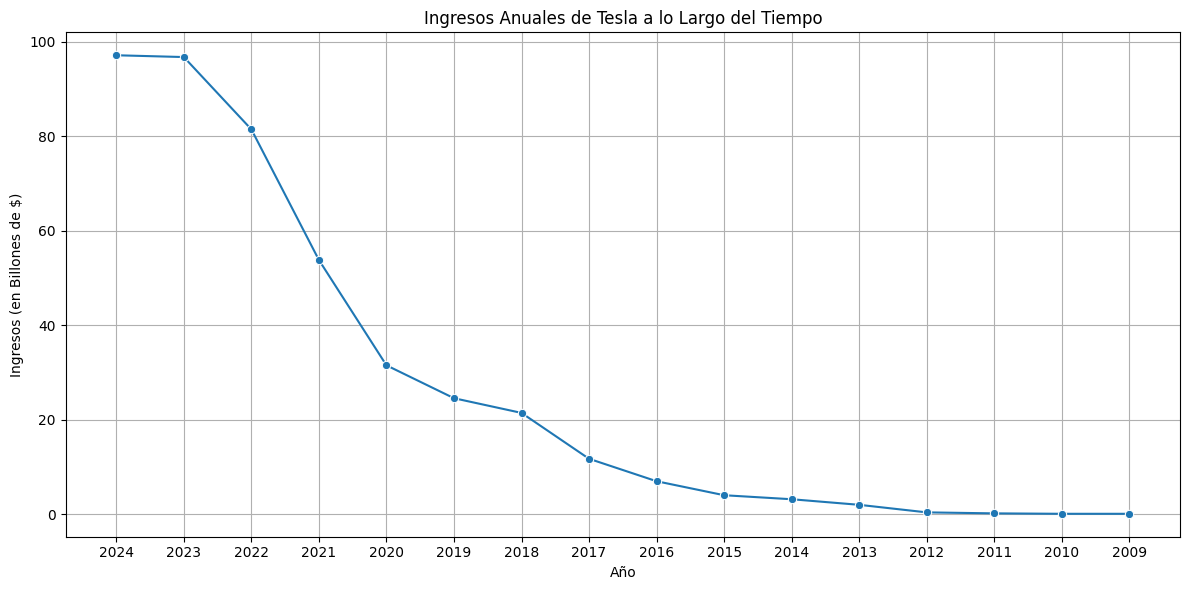

Se ha generado y guardado la línea de tiempo de ingresos anuales desde el DataFrame como 'linea_tiempo_ingresos_tesla_desde_df.png'.


In [213]:

plt.figure(figsize=(12, 6)) 
sns.lineplot(x='fecha', y='Ingresos', data=df_tesla_beneficios, marker='o')
plt.title('Ingresos Anuales de Tesla a lo Largo del Tiempo')
plt.xlabel('Año')
plt.ylabel('Ingresos (en Billones de $)')
plt.grid(True)
plt.tight_layout()
plt.savefig('linea_tiempo_ingresos_tesla_desde_df.png')
plt.show()

print("Se ha generado y guardado la línea de tiempo de ingresos anuales desde el DataFrame como 'linea_tiempo_ingresos_tesla_desde_df.png'.")